#Proyek Analisis Data: Bike Sharing Dataset
* Nama: Faza Azka Mahasya
* Email: fazaazka385@gmail.com
* ID Dicoding: faza_azka_m

#Menentukan Pertanyaan Bisnis
* Bagaimana pengaruh musim terhadap rata-rata jumlah penyewaan sepeda selama tahun 2011–2012?
    
* Pada jam berapa rata-rata jumlah penyewaan sepeda mencapai puncaknya dalam satu hari selama periode 2011–2012?
    
* Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja dan akhir pekan selama tahun 2011–2012?
    
* Bagaimana kondisi cuaca memengaruhi rata-rata jumlah penyewaan sepeda selama periode observasi?

#Import Library

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

#DATA WRANGLING

##Gathering Data

In [89]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [90]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


##Assessing Data

In [91]:
# Informasi dataset
day_df.info()
hour_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [92]:
# Missing values
print("Missing values day_df")
print(day_df.isna().sum())

print("Missing values hour_df")
print(hour_df.isna().sum())

Missing values day_df
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Missing values hour_df
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Missing values day_df
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Missing values hour_df
instant       0
dteday        0
season        0
yr            0
mnth          0
hr     

In [93]:
# Duplikat
print("Jumlah duplikat day_df:", day_df.duplicated().sum())
print("Jumlah duplikat hour_df:", hour_df.duplicated().sum())

Jumlah duplikat day_df: 0
Jumlah duplikat hour_df: 0
Jumlah duplikat day_df: 0
Jumlah duplikat hour_df: 0


In [94]:
# Statistik deskriptif
day_df.describe()
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Insight
1. Tidak ditemukan missing values pada seluruh kolom
   baik pada dataset day_df maupun hour_df.

2. Tidak ditemukan data duplikat yang signifikan,
   namun proses validasi tetap dilakukan untuk memastikan
   kualitas dataset tetap terjaga.

3. Kolom dteday masih bertipe object sehingga perlu
   dikonversi menjadi tipe datetime agar analisis berbasis waktu
   dapat dilakukan dengan lebih akurat.

4. Beberapa kolom seperti instant dan atemp
   tidak digunakan dalam proses analisis sehingga
   dapat dihapus untuk menyederhanakan dataset.

5. Nama kolom seperti cnt, yr, dan mnth
   kurang deskriptif sehingga perlu dilakukan rename
   agar lebih mudah dipahami.

## CLEANING DATA

In [95]:
# Convert datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

In [96]:
# Hapus duplikat
day_df.drop_duplicates(inplace=True)
hour_df.drop_duplicates(inplace=True)

In [97]:
day_df.drop(columns=["instant", "atemp"], inplace=True)
hour_df.drop(columns=["instant", "atemp"], inplace=True)

In [98]:
# Rename kolom
day_df.rename(columns={
    "yr": "year",
    "mnth": "month",
    "cnt": "total_rentals"
}, inplace=True)

hour_df.rename(columns={
    "yr": "year",
    "mnth": "month",
    "cnt": "total_rentals"
}, inplace=True)

print("Cleaning data selesai")

Cleaning data selesai
Cleaning data selesai


In [99]:
# Validasi akhir
print(day_df.isna().sum())
print(hour_df.isna().sum())

dteday           0
season           0
year             0
month            0
holiday          0
weekday          0
workingday       0
weathersit       0
temp             0
hum              0
windspeed        0
casual           0
registered       0
total_rentals    0
dtype: int64
dteday           0
season           0
year             0
month            0
hr               0
holiday          0
weekday          0
workingday       0
weathersit       0
temp             0
hum              0
windspeed        0
casual           0
registered       0
total_rentals    0
dtype: int64
dteday           0
season           0
year             0
month            0
holiday          0
weekday          0
workingday       0
weathersit       0
temp             0
hum              0
windspeed        0
casual           0
registered       0
total_rentals    0
dtype: int64
dteday           0
season           0
year             0
month            0
hr               0
holiday          0
weekday          0
workingday 

#Exploratory Data Analysis (EDA)

### EDA 1 - Pengaruh Musim terhadap Penyewaan

In [100]:
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

season_rentals = (
    day_df.groupby("season")["total_rentals"]
    .agg(["mean", "sum"])
    .reset_index()
)

season_rentals["season"] = season_rentals["season"].map(season_map)

season_rentals

,season,mean,sum
0,Spring,2604.132597,471348
1,Summer,4992.331522,918589
2,Fall,5644.303191,1061129
3,Winter,4728.162921,841613


,season,mean,sum
0,Spring,2604.132597,471348
1,Summer,4992.331522,918589
2,Fall,5644.303191,1061129
3,Winter,4728.162921,841613


Insight:
Berdasarkan hasil analisis, musim Summer dan Fall
memiliki rata-rata serta total jumlah penyewaan sepeda
tertinggi dibandingkan musim lainnya.

Hal ini menunjukkan bahwa kondisi cuaca yang lebih nyaman,
suhu yang lebih stabil, dan meningkatnya aktivitas luar ruangan
mendorong masyarakat lebih aktif menggunakan layanan bike sharing.

Sebaliknya, musim Spring memiliki jumlah penyewaan terendah,
yang menunjukkan bahwa kondisi cuaca yang kurang mendukung
dapat menurunkan minat pengguna.

## EDA 2 - Pola Penyewaan Berdasarkan Jam

In [101]:
hourly_rentals = (
    hour_df.groupby("hr")["total_rentals"]
    .mean()
    .reset_index()
)

hourly_rentals.sort_values(
    by="total_rentals",
    ascending=False
).head()

,hr,total_rentals
17,17,461.452055
18,18,425.510989
8,8,359.011004
16,16,311.983562
19,19,311.523352


,hr,total_rentals
17,17,461.452055
18,18,425.510989
8,8,359.011004
16,16,311.983562
19,19,311.523352


Insight:

Puncak rata-rata penyewaan sepeda terjadi
pada pukul 08.00 serta pukul 17.00–18.00.

Pola ini menunjukkan bahwa layanan bike sharing
lebih dominan digunakan sebagai sarana transportasi harian
(commuting), terutama untuk berangkat kerja,
kuliah, dan perjalanan pulang.

Penggunaan yang lebih rendah pada siang hari
menunjukkan bahwa sepeda lebih banyak digunakan
untuk mobilitas rutin dibandingkan kebutuhan rekreasi.

## EDA 3 - Hari Kerja vs Akhir Pekan

In [102]:
workingday_map = {
    0: "Weekend / Holiday",
    1: "Working Day"
}

workingday_rentals = (
    day_df.groupby("workingday")["total_rentals"]
    .agg(["mean", "sum"])
    .reset_index()
)

workingday_rentals["workingday"] = (
    workingday_rentals["workingday"]
    .map(workingday_map)
)

workingday_rentals

,workingday,mean,sum
0,Weekend / Holiday,4330.168831,1000269
1,Working Day,4584.820000,2292410


,workingday,mean,sum
0,Weekend / Holiday,4330.168831,1000269
1,Working Day,4584.820000,2292410


Insight:

Hari kerja memiliki rata-rata dan total jumlah penyewaan
yang lebih tinggi dibandingkan akhir pekan maupun hari libur.

Hal ini menunjukkan bahwa mayoritas pengguna
memanfaatkan layanan bike sharing untuk kebutuhan mobilitas rutin
seperti bekerja, kuliah, dan aktivitas harian lainnya.

Pada akhir pekan, penggunaan cenderung menurun
karena berkurangnya kebutuhan perjalanan rutin masyarakat.

## EDA 4 - Pengaruh Cuaca terhadap Penyewaan

In [103]:
weather_map = {
    1: "Clear / Partly Cloudy",
    2: "Mist / Cloudy",
    3: "Light Snow / Rain",
    4: "Heavy Rain / Snow"
}

weather_rentals = (
    day_df.groupby("weathersit")["total_rentals"]
    .agg(["mean", "sum"])
    .reset_index()
)

weather_rentals["weathersit"] = (
    weather_rentals["weathersit"]
    .map(weather_map)
)

weather_rentals

,weathersit,mean,sum
0,Clear / Partly Cloudy,4876.786177,2257952
1,Mist / Cloudy,4035.862348,996858
2,Light Snow / Rain,1803.285714,37869


,weathersit,mean,sum
0,Clear / Partly Cloudy,4876.786177,2257952
1,Mist / Cloudy,4035.862348,996858
2,Light Snow / Rain,1803.285714,37869


# VISUALIZATION & EXPLANATORY ANALYSIS

**Pertanyaan 1: Bagaimana pengaruh musim terhadap rata-rata jumlah penyewaan sepeda selama tahun 2011–2012?**
    

    

    


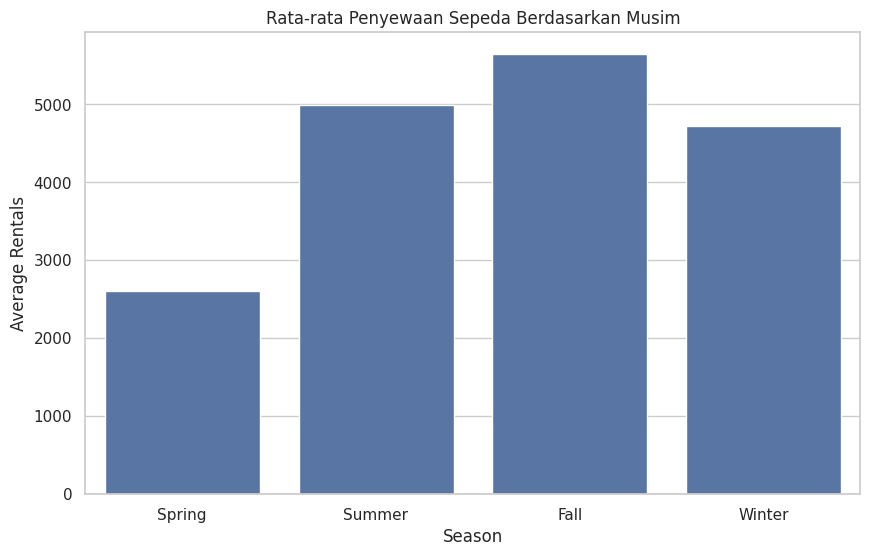

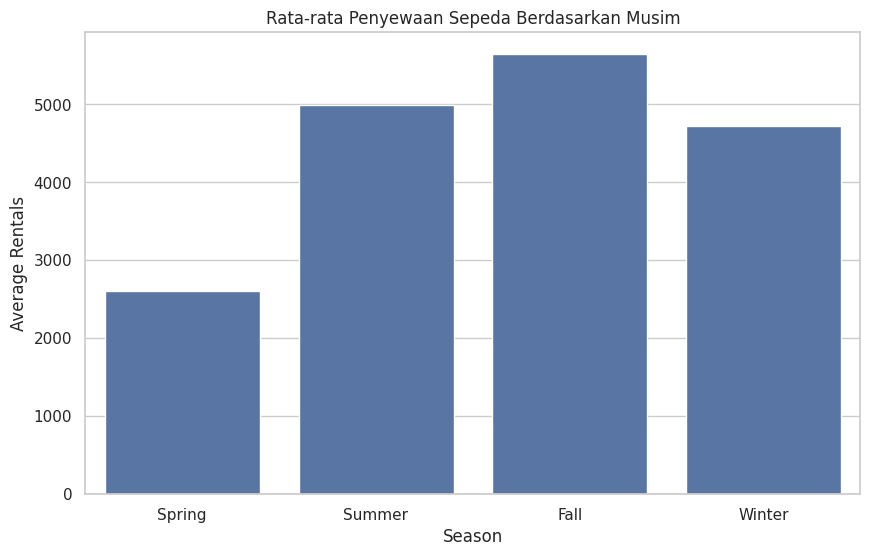

In [104]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=season_rentals,
    x="season",
    y="mean"
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.show()

Insight:

Summer dan Fall menunjukkan rata-rata
jumlah penyewaan sepeda tertinggi dibandingkan musim lainnya.

Hal ini menunjukkan bahwa kondisi cuaca yang lebih nyaman,
suhu yang stabil, dan aktivitas luar ruangan yang meningkat
mendorong masyarakat lebih aktif menggunakan layanan bike sharing.

Sebaliknya,Spring menjadi musim dengan penyewaan terendah
karena kondisi cuaca yang kurang mendukung.

**Pertanyaan 2: Pada jam berapa rata-rata jumlah penyewaan sepeda mencapai puncaknya dalam satu hari selama periode 2011–2012?**

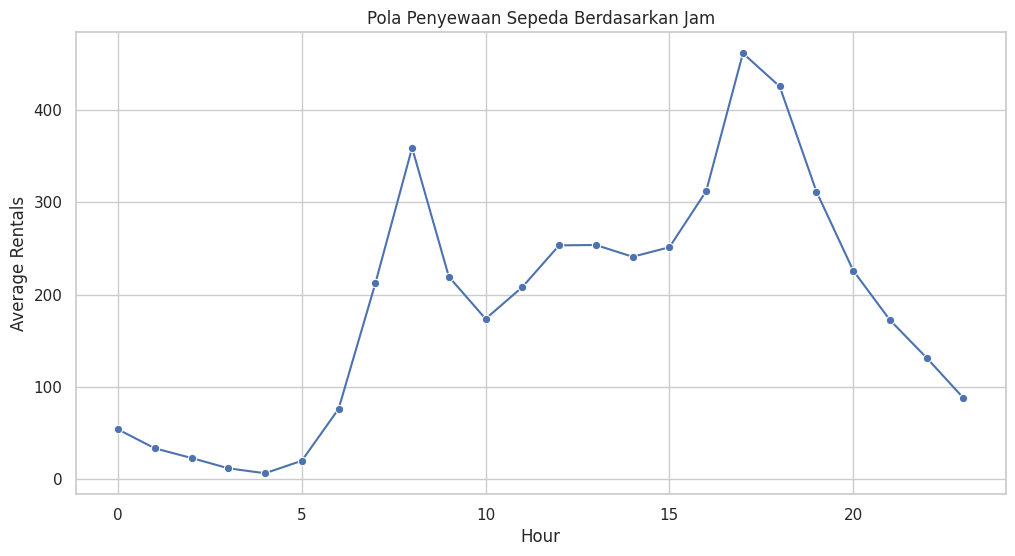

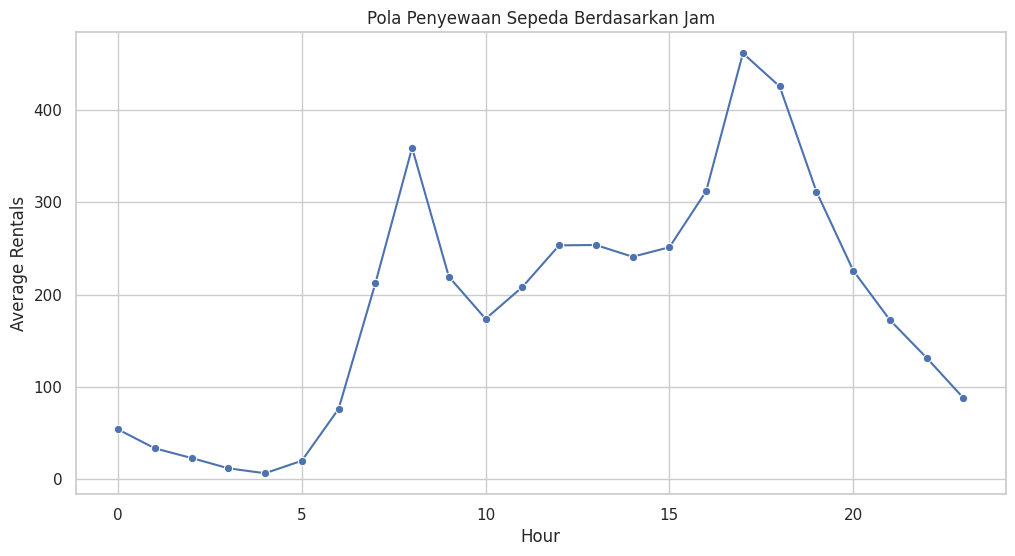

In [105]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_rentals,
    x="hr",
    y="total_rentals",
    marker="o"
)

plt.title("Pola Penyewaan Sepeda Berdasarkan Jam")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.show()

Insight :

Puncak penyewaan terjadi pada pukul 08.00
serta pukul 17.00–18.00.

Pola ini menunjukkan bahwa layanan bike sharing
lebih dominan digunakan untuk aktivitas commuting,
yaitu berangkat kerja, kuliah, dan perjalanan pulang.

Penggunaan yang lebih rendah pada siang hari
menunjukkan bahwa layanan ini lebih sering dimanfaatkan
untuk mobilitas rutin daripada rekreasi.

**Pertanyaan 3: Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja dan akhir pekan selama tahun 2011–2012?**

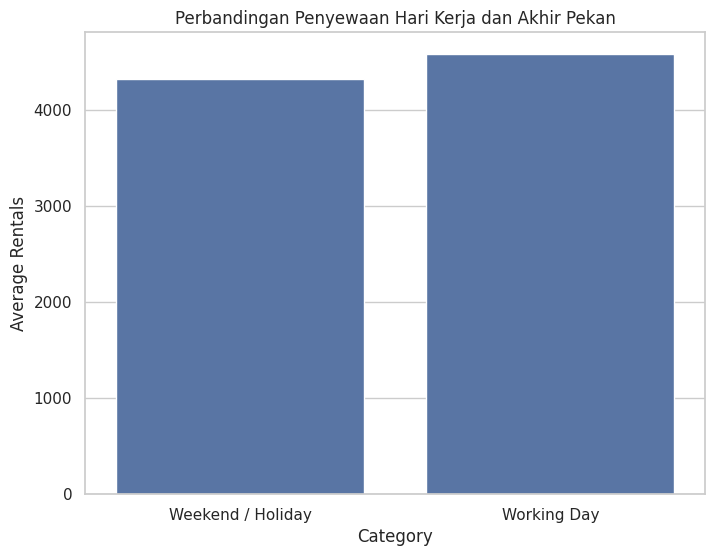

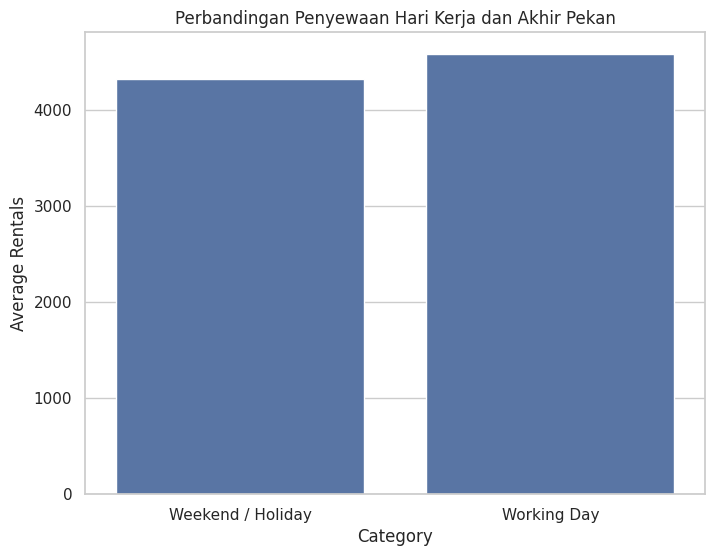

In [106]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=workingday_rentals,
    x="workingday",
    y="mean"
)

plt.title("Perbandingan Penyewaan Hari Kerja dan Akhir Pekan")
plt.xlabel("Category")
plt.ylabel("Average Rentals")
plt.show()

Insight :

Hari kerja memiliki rata-rata jumlah penyewaan
yang lebih tinggi dibandingkan akhir pekan.

Hal ini menunjukkan bahwa mayoritas pengguna
menggunakan layanan bike sharing
untuk kebutuhan mobilitas rutin harian.

Pada akhir pekan, penggunaan menurun
karena aktivitas perjalanan rutin masyarakat juga berkurang.

**Pertanyaan 4:Bagaimana kondisi cuaca memengaruhi rata-rata jumlah penyewaan sepeda selama periode observabold textsi?**

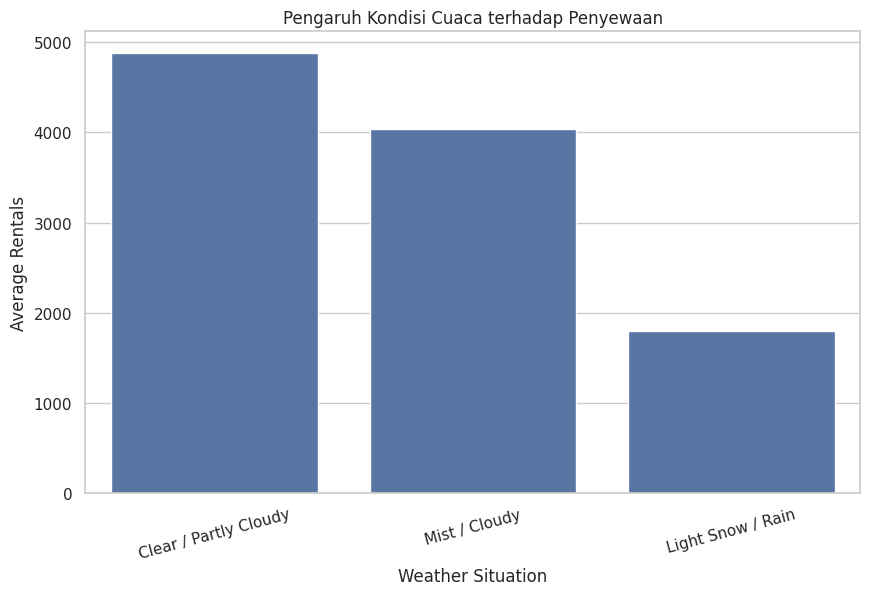

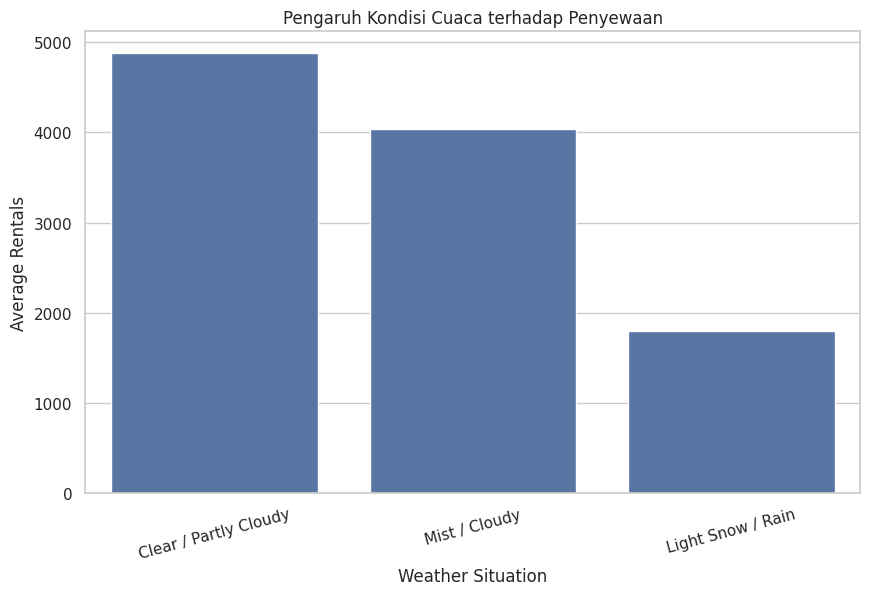

In [107]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=weather_rentals,
    x="weathersit",
    y="mean"
)

plt.title("Pengaruh Kondisi Cuaca terhadap Penyewaan")
plt.xlabel("Weather Situation")
plt.ylabel("Average Rentals")
plt.xticks(rotation=15)
plt.show()

Insight :

Cuaca cerah menghasilkan jumlah penyewaan tertinggi,
sedangkan cuaca buruk seperti hujan dan salju
menyebabkan penurunan penyewaan secara signifikan.

Hal ini menunjukkan bahwa cuaca merupakan faktor penting
dalam keputusan pengguna untuk menggunakan layanan bike sharing.

Pengguna cenderung memilih alternatif transportasi lain
ketika kondisi cuaca tidak mendukung.

#CONCLUSION


##Conclusion
1. Musim Summer dan Fall menjadi periode dengan
   rata-rata serta total penyewaan sepeda tertinggi.
   Kondisi cuaca yang nyaman menjadi faktor utama
   meningkatnya penggunaan bike sharing.

2. Puncak penggunaan sepeda terjadi pada pukul 08.00
   dan 17.00–18.00, yang menunjukkan dominasi penggunaan
   untuk aktivitas commuting atau transportasi rutin.

3. Hari kerja memiliki jumlah penyewaan lebih tinggi
   dibandingkan akhir pekan dan hari libur,
   karena mayoritas pengguna menggunakan sepeda
   untuk bekerja, kuliah, dan aktivitas harian.

4. Cuaca cerah menghasilkan jumlah penyewaan tertinggi,
   sedangkan cuaca buruk menurunkan jumlah penggunaan
   secara signifikan.


##Rekomendasi Akhir

1. Menambah jumlah sepeda dan kesiapan operasional
   pada musim Summer dan Fall karena permintaan
   cenderung meningkat secara signifikan.

2. Menyediakan lebih banyak unit sepeda
   pada jam sibuk pagi dan sore hari
   untuk memenuhi kebutuhan pengguna commuting.

3. Memberikan promo khusus pada akhir pekan
   untuk meningkatkan penggunaan sepeda
   di luar hari kerja.

4. Menyusun strategi promosi berbasis cuaca,
   seperti diskon saat cuaca mendung ringan
   untuk menjaga stabilitas jumlah penyewaan.

5. Fokus mempertahankan pengguna registered
   karena mereka merupakan kontributor utama
   dalam total penyewaan sepeda secara keseluruhan.